In [68]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import HARP_and_age as haa
import all_nu_analysis as ana

import pickle
import importlib

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u

from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x378042680>

In [2]:
with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)

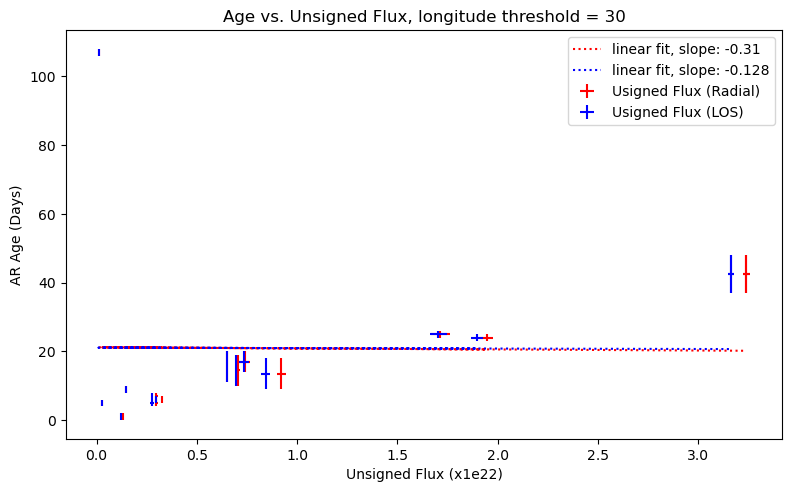

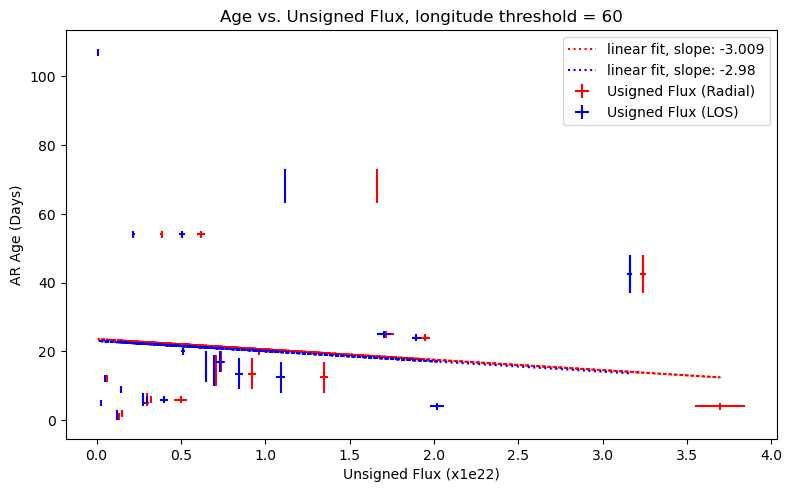

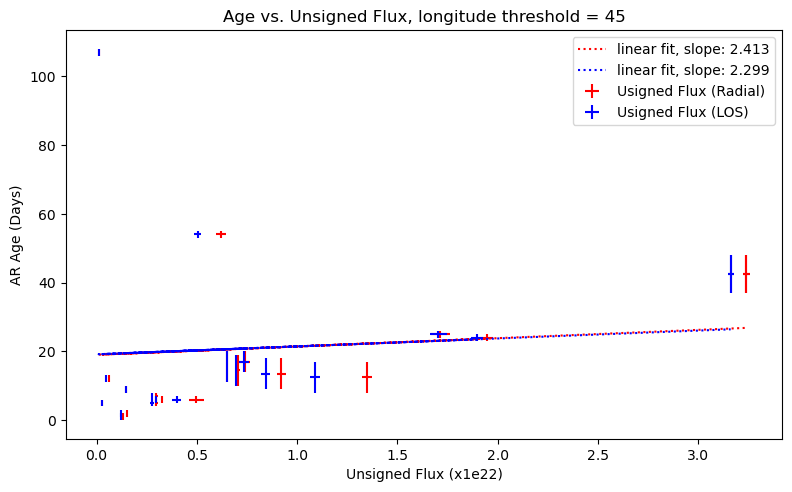

In [4]:
#Unsigned flux vs. AGE

#ages, hparr, hparl, heli, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=30)
magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=30)
print('')
magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60)
print('')
#ages, hparr, hparl, heli, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=45)
magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=45)

#ages, hparr, hparl, heli, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=45)
#magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=80)

/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jmdunca2/do-dem//dodem/HARP_and_age.py:802: RuntimeWarning: invalid value

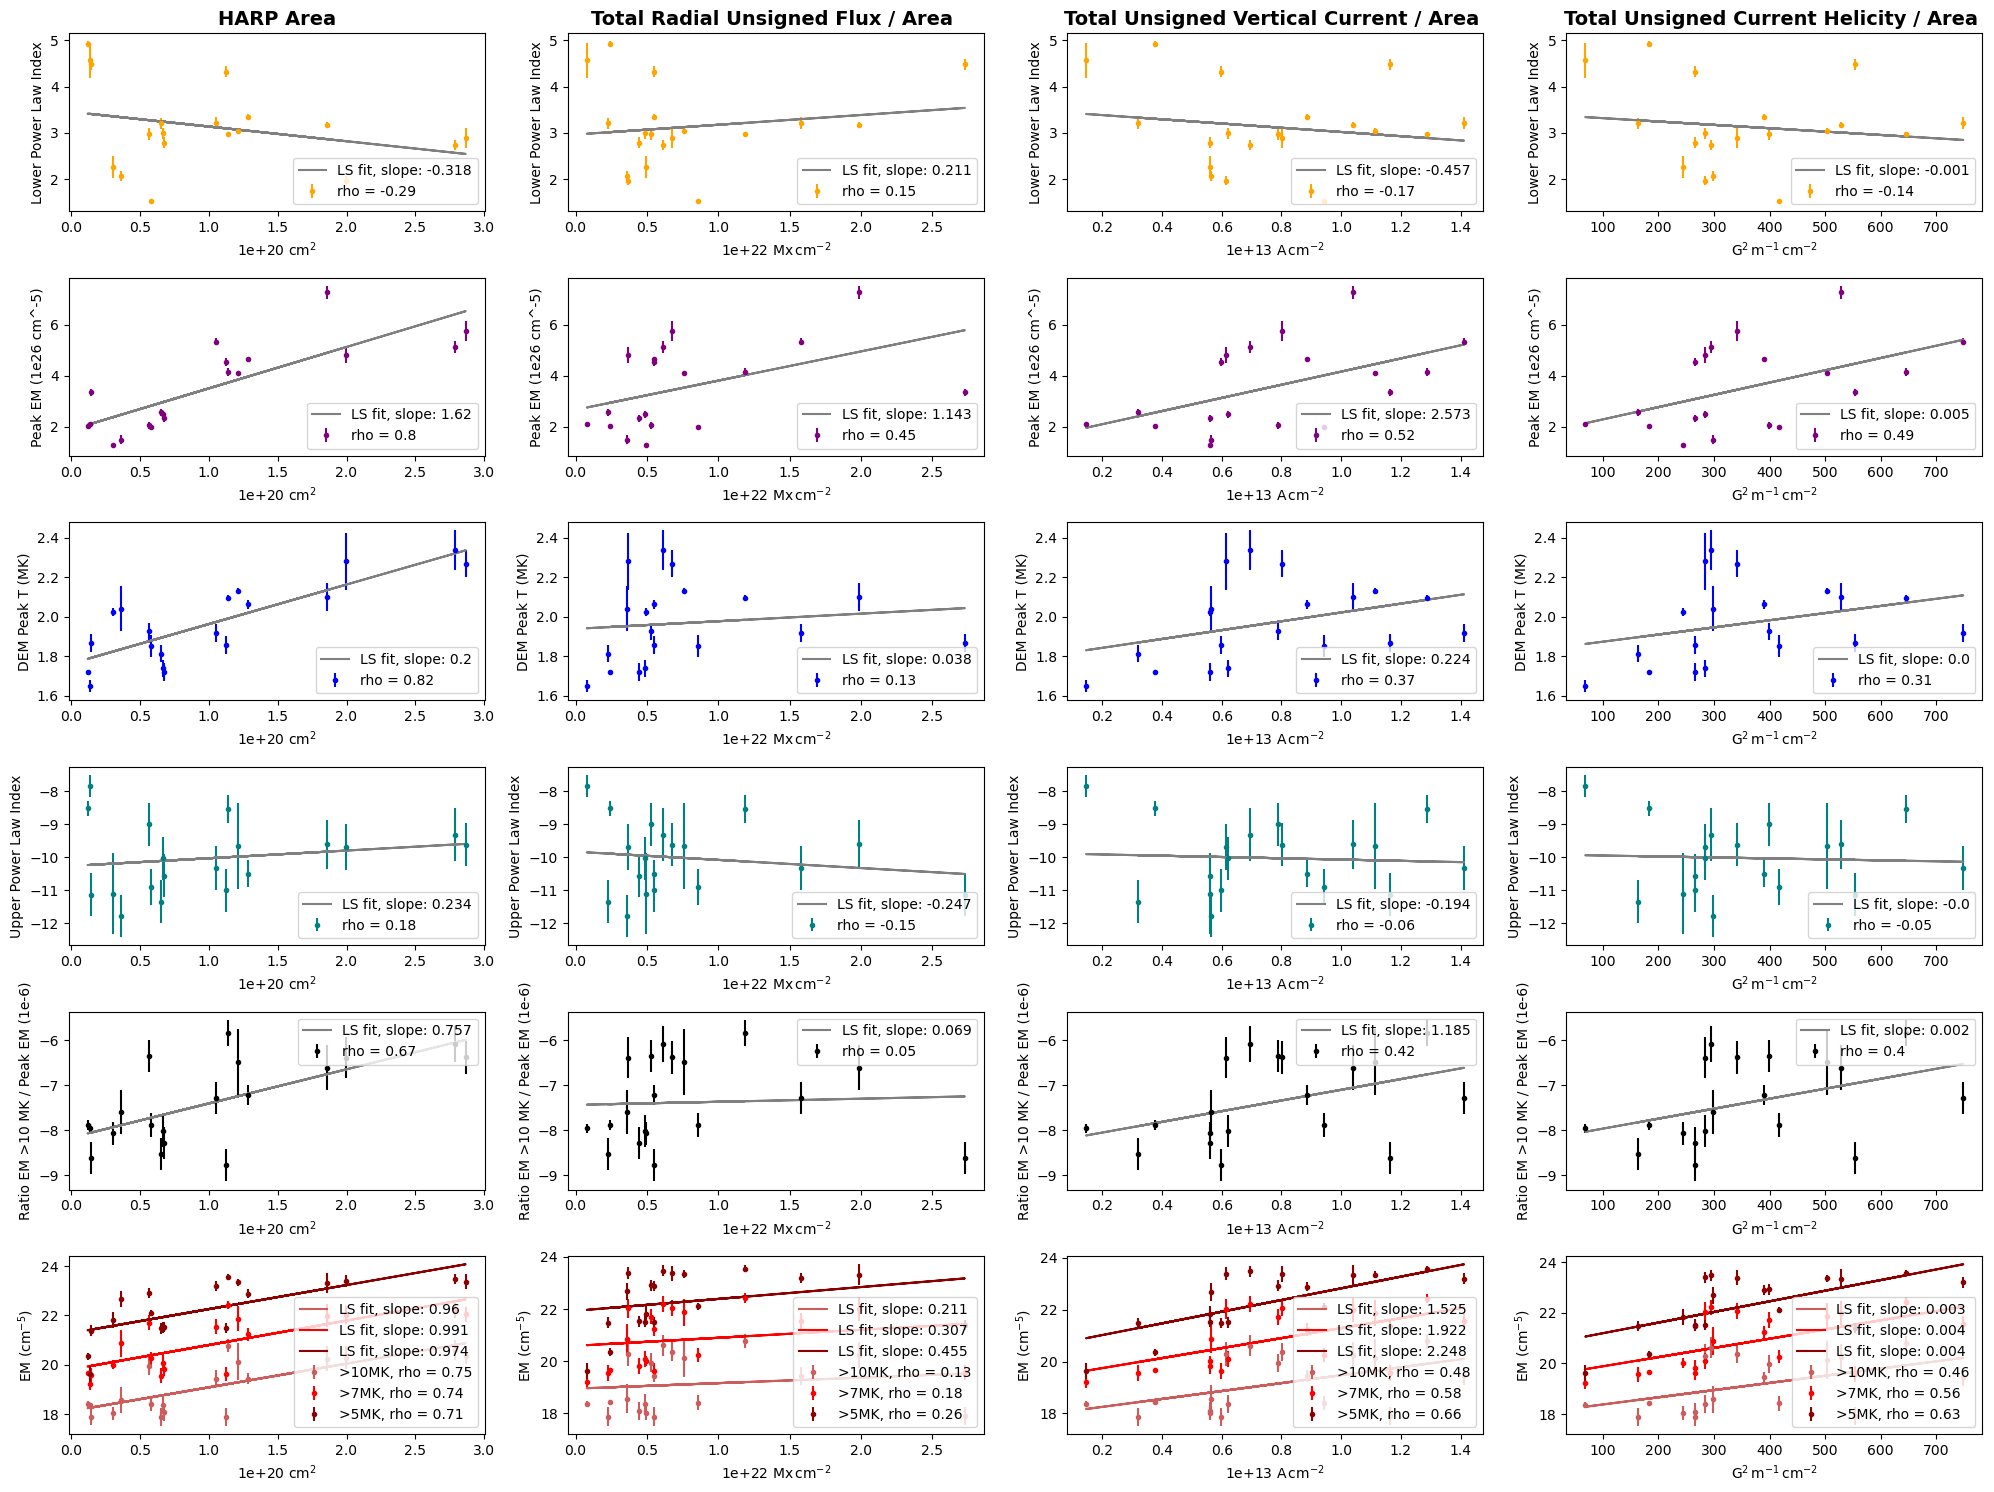

In [5]:
#MEGAPLOT - NICE VERSION
#We do want to normalize other parameters by HARP area, and also add a plot vs. HARP area. 
importlib.reload(haa)

params = ['lowerpower2', 'peak_em', 'peak', 'upperpower2', 'above10rat', 'above10', 'above7', 'above5']
paramlabels = ['Lower Power Law Index', 'Peak EM (1e26 cm^-5)', 'DEM Peak T (MK)', 
               'Upper Power Law Index', 
               'Ratio EM >10 MK / Peak EM (1e-6)',
               'EM ('+(u.cm**(-5)).to_string('latex_inline')+')',
              'EM ('+(u.cm**(-5)).to_string('latex_inline')+')',
              'EM ('+(u.cm**(-5)).to_string('latex_inline')+')']

tcolors = ['orange', 'purple', 'blue', 'teal', 'black', 'indianred', 'red', 'darkred']
skh = [False, False, False, False, False, False, False, False]

mparams = ['areas', 'usflx', 'tuvc', 'tuheli'] #['areas', 'mheli', 'malp']
normcheck = [False, True, True, True] #[False, False, False, False]

magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)

regions = magparams['regions']['vals']

#fig, axes = plt.subplots(len(params),len(mparams), figsize=(5*len(mparams), 3*len(params)), tight_layout = {'pad': 1})
fig, axes = plt.subplots(6,len(mparams), figsize=(5*len(mparams), 3*5), tight_layout = {'pad': 1})


#For each DEM parameter
for i in range(0, len(params)):
    #For each magnetic parameter
    for j in range(0, len(mparams)):

        #Get the DEM parameter values, ages, standard deviations (of parameter values), and sub-region labels
        #for all regions.
        dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                    skiphuh=skh[i])

        #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
        trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
        yerr_ = stdvs[trs]
        wwy = [1/y for y in yerr_]
        

        #Plot vs. radial unsigned flux.
        if params[i] in ['above5', 'above7']:
            ax=axes[5,j]
        else:
            ax=axes[i,j]
        magpar=magparams[mparams[j]]['vals']
        #Normalize by region area for all parameters where it's selected in normcheck above. Don't normalize area by area.
        if normcheck[j]:
            norm=magparams[mparams[j]]['norm']*(magparams['areas']['vals'][:,0]/1e20)
        else:
            norm=magparams[mparams[j]]['norm']

        herr = magpar[:,1]/norm 
        wwx = [1/y for y in herr]
    
        #[print(s) if (s not in sks) else print('') for s in regions]
        rho=round(np.corrcoef(magpar[:,0]/norm, dataparam[trs,0])[0,1],2)
        #print(rho)
        if params[i] in ['above5', 'above7', 'above10']:
            extra_labs = ['>10MK', '>7MK', '>5MK']
            ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3, label=extra_labs[i-5]+', '+'rho = '+str(rho))
        else:    
            ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3, label='rho = '+str(rho))

        # #Fit option with y weights only
        m, b = np.polyfit(magpar[:,0]/norm, dataparam[trs,0], 1) #, w=wwy)
        fity = np.array(magpar[:,0]/norm)*m + b
        if params[i] in ['above5', 'above7', 'above10']:
            ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color=tcolors[i]) 
        else:
            ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')
            
        #print(m)

        if i==0 and j==0:
            import copy
            savemg = copy.deepcopy(magpar[:,0]/norm)
            saved = copy.deepcopy(dataparam[trs,0])
            swwy = copy.deepcopy(wwy)
        
        fsz=14
        fw='bold'
        if normcheck[j]:
            normunit = magparams[mparams[j]]['unit']/magparams['areas']['unit']
            
            if magparams[mparams[j]]['norm'] != 1:
                #ax.set_xlabel(magparams[mparams[j]]['name']+'/ HARP Area ('+"{:.0e}".format(magparams[mparams[j]]['norm'])+' '+normunit.to_string('latex_inline')+')')
                ax.set_xlabel("{:.0e}".format(magparams[mparams[j]]['norm'])+' '+normunit.to_string('latex_inline'))
                if i==0:
                    ax.set_title(magparams[mparams[j]]['name']+' / Area ', fontweight=fw, fontsize=fsz)
            else:
                #ax.set_xlabel(magparams[mparams[j]]['name']+'/ HARP Area ('+normunit.to_string('latex_inline')+')')
                ax.set_xlabel(normunit.to_string('latex_inline'))
                if i==0:
                    ax.set_title(magparams[mparams[j]]['name']+' / Area ', fontweight=fw, fontsize=fsz)
        else:
            if magparams[mparams[j]]['norm'] != 1:
                #ax.set_xlabel(magparams[mparams[j]]['name']+' ('+"{:.0e}".format(magparams[mparams[j]]['norm'])+' '+magparams[mparams[j]]['unit'].to_string('latex_inline')+')')
                ax.set_xlabel("{:.0e}".format(magparams[mparams[j]]['norm'])+' '+magparams[mparams[j]]['unit'].to_string('latex_inline'))
                if i==0:
                    ax.set_title(magparams[mparams[j]]['name'], fontweight=fw, fontsize=fsz)
            else:
                #ax.set_xlabel(magparams[mparams[j]]['name']+' ('+magparams[mparams[j]]['unit'].to_string('latex_inline')+')')
                ax.set_xlabel(magparams[mparams[j]]['unit'].to_string('latex_inline'))
                #For when running with mean params, above doesn't work.
                #ax.set_xlabel(magparams[mparams[j]]['unit'])
                if i==0:
                    ax.set_title(magparams[mparams[j]]['name'], fontweight=fw, fontsize=fsz)
            
        ax.set_ylabel(paramlabels[i])
        ax.legend(loc='lower right')
        if i==4:
            ax.legend(loc='upper right')


plt.savefig('all_mag_params_extensive_em_area_normalized_addrat_ghostcorr_cstat.png')


New round of plots – exploring shape of DEM

- peak temperature (T) vs. amount of material above 10 MK
- peak EM vs. amount of EM above 10 MK
- peak temperature (T) vs. peak EM
- peak temperature, EM vs. AR age

Giant corner plot!

In [62]:
10**6.51

3235936.569296281

In [54]:
print(10**6.2/1e6, 10**6.36/1e6) 

1.584893192461114 2.2908676527677745


In [55]:
print(10**(26.05574119297303), 10**(26.86088783075433))

1.1369495470139038e+26 7.259184435619227e+26


In [61]:
print(10**(-8.910458345623903), 10**(-5.4367060188440695))

1.228971054913844e-09 3.6584235258602637e-06


In [57]:
1/((100**2)/(np.pi*(150)**2))

7.068583470577035

In [56]:
360*360

129600

In [ ]:
np.array(region_10overpeak)[:,0]

/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jmdunca2/do-dem//dodem/HARP_and_age.py:802: RuntimeWarning: invalid value

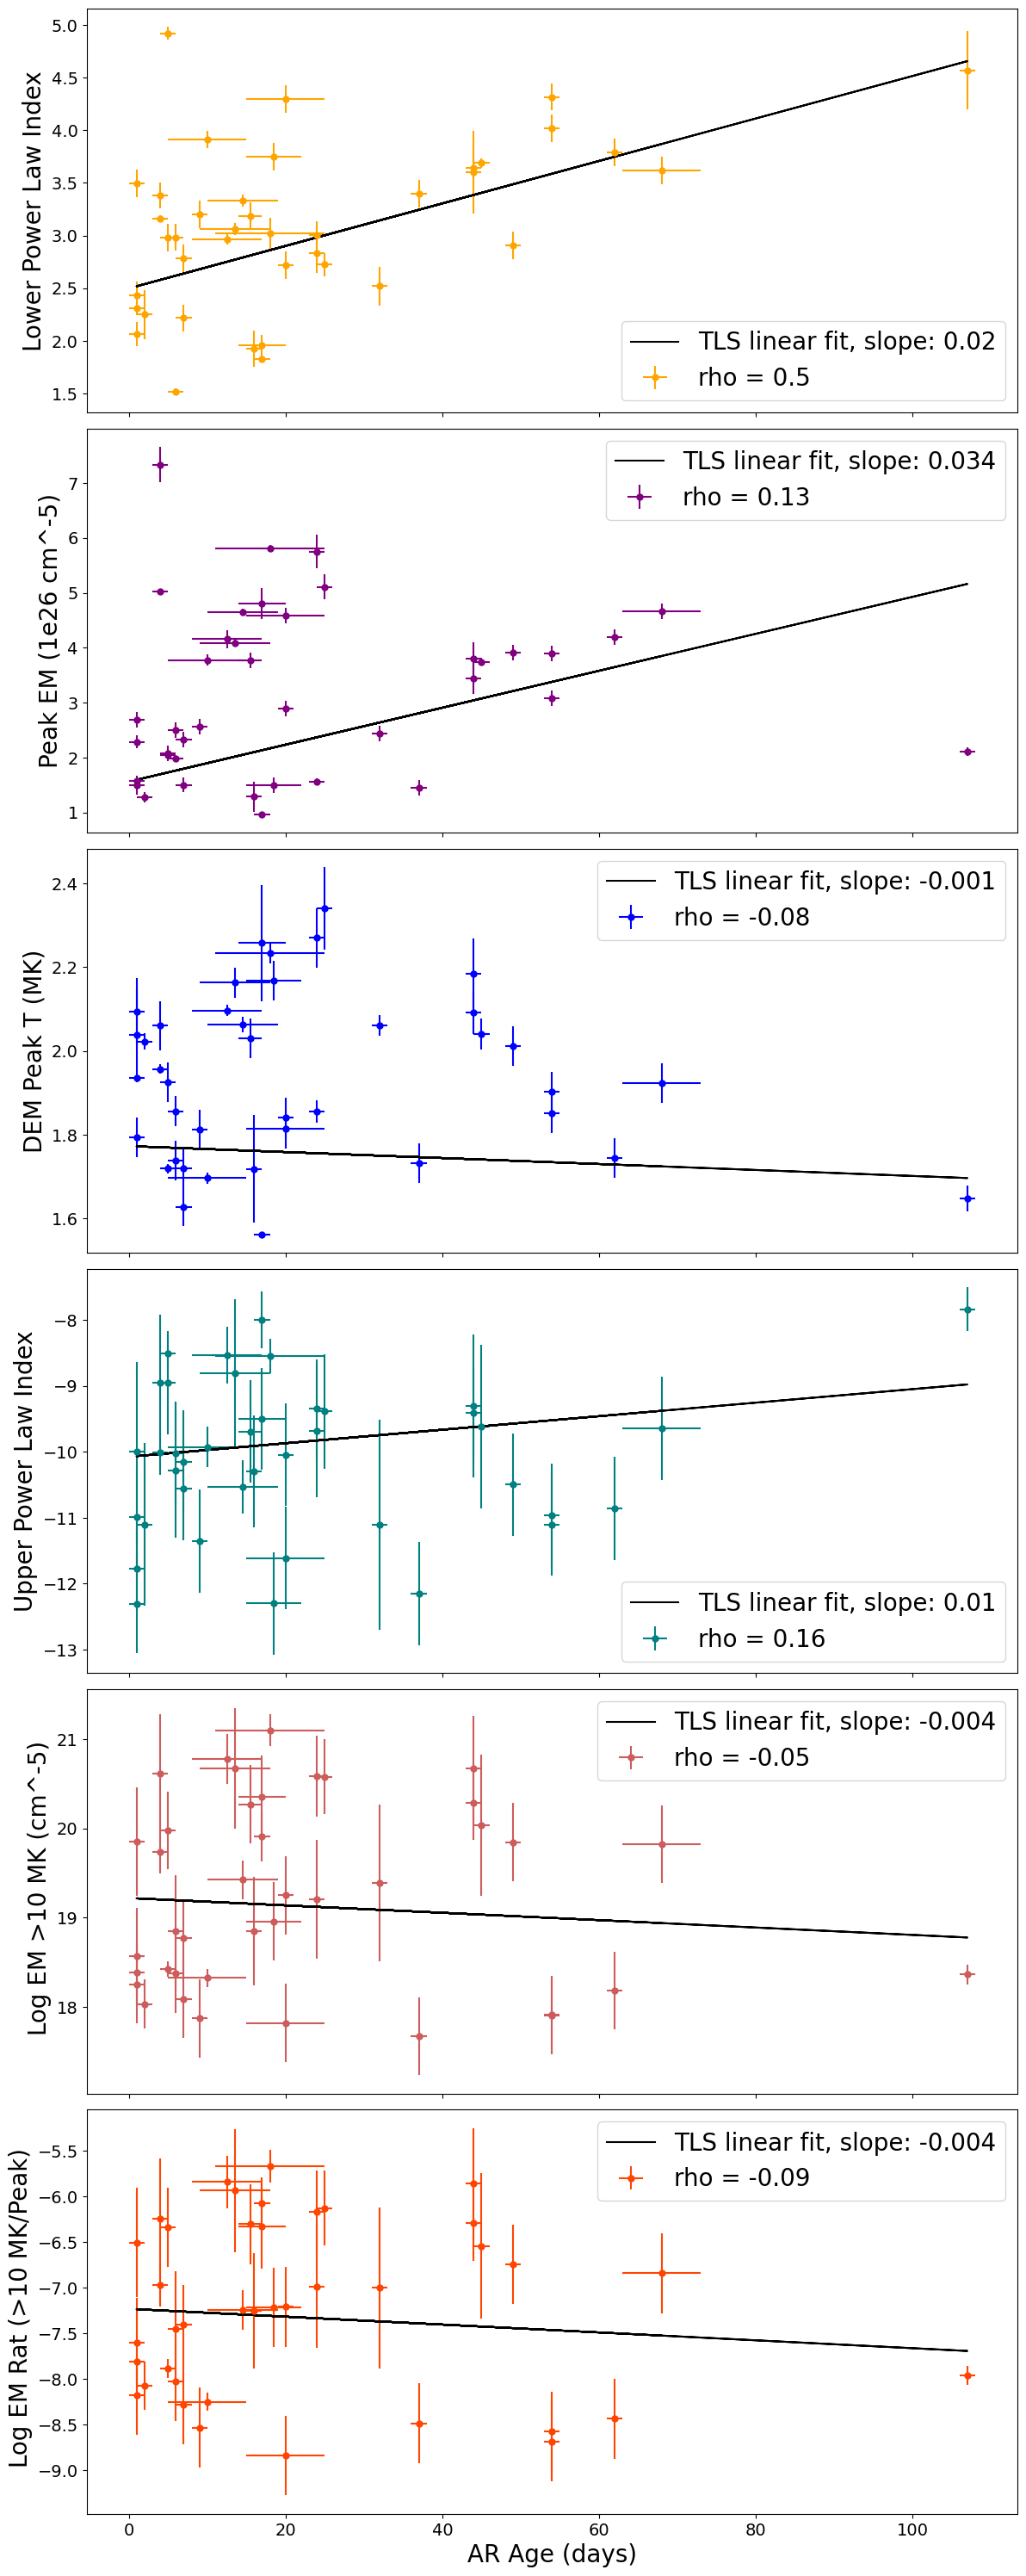

In [14]:
#MEGAPLOT - AREA NORMALIZED
importlib.reload(haa)

from scipy import odr

#ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

def f(B, x):
    #Linear function
    return B[0]*x + B[1]
    
linear = odr.Model(f)

params = ['lowerpower2', 'peak_em', 'peak', 'upperpower2', 'above10', 'above10rat']
paramlabels = ['Lower Power Law Index', 'Peak EM (1e26 cm^-5)', 
               'DEM Peak T (MK)', 'Upper Power Law Index', ' Log EM >10 MK (cm^-5)', ' Log EM Rat (>10 MK/Peak)']#' Log EM >10 MK (cm^-5)']
tcolors = ['orange', 'purple', 'blue', 'teal', 'indianred', 'orangered']
skh = [False, False, False, False, False, False]


labelsize=20

fig, axes = plt.subplots(len(params),1, figsize=(12, 5*len(params)), tight_layout = {'pad': 1}, sharex='col')

for i in range(0, len(params)):

    dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                skiphuh=skh[i])

    yerr_ = stdvs
    wwy = [1/y for y in yerr_]
    

    #Plot vs. age
    ax=axes[i]



    herr = ages[:,0]-ages[:,1]
    wwx = [1/y for y in herr]

    #[print(s) if (s not in sks) else print('') for s in regions]

    rho=round(np.corrcoef(ages[:,0], dataparam[:,0])[0,1],2)
    ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=herr, 
                linestyle='none', marker='o', markersize=5, label='rho = '+str(rho))

    # #Fit option with y weights only
    # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=wwy)
    # fity = np.array(ages[:,0])*m + b
    # ax.plot(ages[:,0], fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  

    #Fit option with both weights
    mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
    myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
    myoutput = myodr.run()
    #myoutput.pprint()
    m, b = myoutput.beta
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, label='TLS linear fit, slope: '+str(round(m,3)), color='black')


    if i==len(params)-1:
        ax.set_xlabel('AR Age (days)', fontsize=labelsize)
    ax.set_ylabel(paramlabels[i], fontsize=labelsize)
    ax.legend(fontsize=labelsize)
    ax.tick_params(axis='both', which='major', labelsize=14) 


plt.savefig('all_DEM_params_vs_age_ghostcorr_list4.png')

In [ ]:
with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
filelist, agelist = ana.get_same_region_file_lists(samesames, all_targets, get_agelists=True, aiaxrt=True)
filelist_no, agelist = ana.get_same_region_file_lists(samesames, all_targets, get_agelists=True, noxrt=True)
filelist_all, agelist = ana.get_same_region_file_lists(samesames, all_targets, get_agelists=True)


fnlist=[]
falist=[]
xagelist=[]
for i in range(0, len(filelist)):
    f = filelist[i]
    fa = filelist_all[i]
    fn = filelist_no[i]
    if f:
        xagelist.append(agelist[i])
        fas = []
        fns = []
        for file in f:
            timestring = file.split('/')[-2]
            #print(timestring)
            for afile in fa:
                if timestring in afile:
                    fas.append(afile)
            for nfile in fn:
                if timestring in nfile:
                    fns.append(nfile)

        falist.append(fas)
        fnlist.append(fns)
        #print('')

make_cornerplot(falist, xagelist, title='yesxrt_comp')
make_cornerplot(fnlist, xagelist, title='noxrt_comp')

In [ ]:

filez = all_targets['01-nov-14_1']['res_file_dict(s)'][0]['quiet files all-inst']
a5s=[]
for f_ in filez:
    with open(f_, 'rb') as f:
        data = pickle.load(f)


    print('max: ', data['max'], data['max_temp'])
    print(data['above_5MK'][0])
    a5s.append(data['above_5MK'][0])
    print(data['above_7MK'])
    print(data['above_10MK'])
    print(data['powerlaws2'])
    print(data['powerlaws'])
    print('')

np.mean(a5s)

In [ ]:
samesames

In [ ]:

filez = all_targets['29-may-18_1']['res_file_dict(s)'][0]['quiet files all-inst']

for f_ in filez:
    with open(f_, 'rb') as f:
        data = pickle.load(f)


    print('max: ', data['max'], data['max_temp'])
    print(data['above_5MK'])
    print(data['above_7MK'])
    print(data['above_10MK'])
    print(data['powerlaws2'])
    print(data['powerlaws'])
    print('')

In [ ]:
mparams = ['usflx', 'tuvc', 'tuheli', 'mheli', 'malp', 'areas']

fig, axes = plt.subplots(2,3, figsize=(3*len(mparams), 6), tight_layout = {'pad': 1})

magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)

regions = magparams['regions']['vals']

dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param='peak', return_stdvs=True,
                                                    skiphuh=False)

#Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]

ages = ages[trs,0]

for j in range(0, len(mparams)):
    print(j%3,int(j/3))
    ax=axes[int(j/3), j%3]
    magpar=magparams[mparams[j]]['vals']
    norm=magparams[mparams[j]]['norm']
    areanorm=1e20

    herr = magpar[:,1]/norm 
    wwy = [1/y for y in herr]

    #area=magparams['areas']['vals'][:,0]/areanorm
    
    
    rho=round(np.corrcoef(ages, magpar[:,0]/norm)[0,1],2)
    ax.errorbar(ages, magpar[:,0]/norm, color=tcolors[i], #yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3, label='rho = '+str(rho))
    
    #Fit option with y weights only
    m, b = np.polyfit(ages, magpar[:,0]/norm, 1) #, w=wwy)
    fity = np.array(ages)*m + b
    ax.plot(ages, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  


    
    if norm != 1:
        ax.set_ylabel(magparams[mparams[j]]['name']+' ('+"{:.0e}".format(norm)+')')
    else:
        ax.set_ylabel(magparams[mparams[j]]['name'])

    #ax.axvline((((150*u.arcsec*750*(u.km/u.arcsec))**2).to(u.cm**2).value)/areanorm, color='red', label='DEM Region Area')
    ax.set_xlabel('AR Age (days)')
    ax.legend()    

plt.savefig('mag_params_vs_AGE.png')

Below: draft versions and other explorations. 

In [ ]:
#MEGAPLOT - AREA NORMALIZED
importlib.reload(haa)

params = ['lowerpower2', 'peak', 'upperpower2', 'above10']
paramlabels = ['Lower Power Law Index', 'DEM Peak T (MK)', 'Upper Power Law Index', 'EM >10 MK (cm^-5)']
tcolors = ['orange', 'blue', 'teal', 'indianred']
skh = [False, False, False, False]

mparams = ['usflx', 'tuvc', 'tuheli', 'mheli', 'malp']

magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)

regions = magparams['regions']['vals']

fig, axes = plt.subplots(len(params),len(mparams), figsize=(5*len(mparams), 3*len(params)), tight_layout = {'pad': 1})

for i in range(0, len(params)):
    for j in range(0, len(mparams)):

        dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                    skiphuh=skh[i])

        #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
        trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
        yerr_ = stdvs[trs]
        wwy = [1/y for y in yerr_]
        

        #Plot vs. radial unsigned flux.
        ax=axes[i,j]
        magpar=magparams[mparams[j]]['vals']
        norm=magparams[mparams[j]]['norm']*(magparams['areas']['vals'][:,0]/1e20)

        herr = magpar[:,1]/norm 
        wwx = [1/y for y in herr]
    
        #[print(s) if (s not in sks) else print('') for s in regions]
        rho=round(np.corrcoef(magpar[:,0]/norm, dataparam[trs,0])[0,1],2)
    
        ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3, label='rho = '+str(rho))

        # #Fit option with y weights only
        m, b = np.polyfit(magpar[:,0]/norm, dataparam[trs,0], 1, w=wwy)
        fity = np.array(magpar[:,0]/norm)*m + b
        ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  


        
        if magparams[mparams[j]]['norm'] != 1:
            ax.set_xlabel('AREA NORMALIZED '+magparams[mparams[j]]['name']+' ('+"{:.0e}".format(magparams[mparams[j]]['norm'])+' '+magparams[mparams[j]]['unit'].to_string('latex')+')')
        else:
            ax.set_xlabel('AREA NORMALIZED '+magparams[mparams[j]]['name'])
        ax.set_ylabel(paramlabels[i])
        ax.legend()


plt.savefig('all_mag_params_area_normalized_postacc.png')

In [ ]:
from astropy import units as u
q=1e20*(u.cm)**2

print(f"{q:latex}")

In [ ]:
"""
Let's look more at some POWERLAWS - what do we get with the AIA-only DEM results? Looks like we replicate a similar 
relationship (good sanity check). 

"""

fig, axes = plt.subplots(2,2, figsize=(12, 6), tight_layout = {'pad': 1})


params = ['lowerpower', 'lowerpower2', 'lowerpower', 'lowerpower2']
         #'upperpower2', 'lowerpower2']
tcolors = ['indianred', 'orange', 'indianred', 'orange']
skh = [False, False, True, True]

i=1

for i in range(0, len(params)):

    dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], 
                                                     return_stdvs=True, filetype='quiet files onlyaia',
                                                    skiphuh=skh[i])  
    
    #print(dataparam.shape)
    #print(dataparam)
    #print(ages)
    #print(stdvs)
    
    
    
    ax=axes[(i//2),(i%2)]
    
    yerr_ = stdvs
    #print(yerr_)
    yerr1=yerr_

    #Trying to keep the stdv-weighted fit from being tugged away from the rest of the values by cases with only a few measurements
    ww = [1/y if y > 0.02 else 0.1*np.mean(yerr_) for y in yerr_]
    #print(ww)
    
    ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, linestyle='none', marker='o', markersize=3, label='stdv')
    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=ww)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='linear fit, slope: '+str(round(m,3)), color=tcolors[i])
    
    yerr_ = dataparam[:,1]
    #print('fit error > stdv: ', len(np.where(yerr_/yerr1 > 1.)[0]), len(yerr_))
    #ww = [1/y if y != 0 else np.mean(yerr_)/10 for y in yerr_]
    
    ax.errorbar(ages[:,0]-0.5, dataparam[:,0], color='blue', yerr=yerr_, linestyle='none', marker='o', markersize=3, label='fit error')
    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=1/yerr_)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='linear fit, slope: '+str(round(m,3)), color='blue')

    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')
    
    ax.set_title(params[i])
    ax.legend(loc='lower right')


print('Top panels: all regions')
print('Bottom panels: no 12-sep-17, 13-sep-17, 03-may-21_1, 03-may-21_2 (fit issues)')

In [ ]:
"""
Investigating various options for plotting/fitting/uncertainties, etc. for DEM power laws for the "all instrument"
(e.g. at least NuSTAR+AIA, sometimes with XRT) DEM results at quiet times. 

The conclusion for now is that we will use:

Lower Power Law:

-Modified fit method (upper boundary is index of DEM max + 1 - not fixed value)
-STDV of results from different time intervals as uncertainty. For cases with fewer than three time intervals, use the mean of all the 
    other (>3 measurement) cases.
-Linear trend fit uses both age and power law uncertainties. 

Upper Power Law:

-Modified fit method (upper boundary is temp. closest to logT=6.35 + 3 temp bin. - not + 1 temp bin)
-STDV of results from different time intervals as uncertainty. For cases with fewer than three time intervals, use the mean of all the 
    other (>3 measurement) cases.
-Linear trend fit uses both age and power law uncertainties. 
"""

fig, axes = plt.subplots(4,2, figsize=(12, 12), tight_layout = {'pad': 1})


params = [ 'upperpower', 'lowerpower',
         'upperpower2', 'lowerpower2',
         'lowerpower', 'lowerpower2']
tcolors = ['pink', 'indianred', 'powderblue', 'orange', 'indianred', 'orange']
skh = [False, False, False, False, True, True]

titles = ['Upper Power - og fit', 'Lower Power - og fit', 'Upper Power - modified fit', 'Lower Power - modified fit',
          'Upper Power - modified fit - remove bad fit cases', 'Lower Power - modified fit - remove bad fit cases',
          'Upper Power - modified fit - add age error', 'Lower Power - modified fit - add age error']



for i in range(0, len(params)):

    dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                    skiphuh=skh[i])  
    
    #print(dataparam.shape)
    #print(ages)
    #print(stdvs)
    
    
    
    ax=axes[(i//2),(i%2)]
    
    yerr_ = stdvs
    #print(yerr_)

    #Trying to keep the stdv-weighted fit from being tugged away from the rest of the values by cases with only a few measurements
    ww = [1/y if y > 0.02 else 1/np.mean(yerr_) for y in yerr_]
    #print(ww)
    
    ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, linestyle='none', marker='o', markersize=3, label='stdv')
    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=ww)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='linear fit, slope: '+str(round(m,3)), color=tcolors[i])
    
    yerr_ = dataparam[:,1]
    #ww = [1/y if y != 0 else np.mean(yerr_)/10 for y in yerr_]
    
    ax.errorbar(ages[:,0]-0.5, dataparam[:,0], color='blue', yerr=yerr_, linestyle='none', marker='o', markersize=3, label='fit error')
    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=1/yerr_)
    #print(m,b)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='linear fit, slope: '+str(round(m,3)), color='blue')

    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')
    
    ax.set_title(titles[i])
    ax.legend(loc='lower right')


from scipy import odr

#ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

def f(B, x):
    #Linear function
    return B[0]*x + B[1]
    
linear = odr.Model(f)


params = ['upperpower2', 'lowerpower2']
tcolors = ['powderblue', 'orange']
skh = [False, False]

for i in range(0, len(params)):

    dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                    skiphuh=skh[i])  

    
    ax=axes[3,(i%2)]
    
    yerr_ = stdvs
    ageerr = ages[:,0]-ages[:,1]
    #print(ageerr)
    
    #print(yerr_)

    #Trying to keep the stdv-weighted fit from being tugged away from the rest of the values by cases with only a few measurements
    wwy = [1/y if y > 0.02 else np.mean(yerr_) for y in yerr_]
    wwx = [1/y for y in ageerr]
    #print(wwy)
    #print(wwx)
    
    
    ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
                linestyle='none', marker='o', markersize=3, label='stdv')

    mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
    myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
    myoutput = myodr.run()
    #myoutput.pprint()
    m, b = myoutput.beta
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])
    
    # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1, w=ww)
    # fity = np.array(ages[:,0])*m + b
    # ax.plot(ages[:,0], fity, linestyle='dotted', label='linear fit, slope: '+str(round(m,3)), color=tcolors[i])
    
    yerr_ = dataparam[:,1]
    
    ax.errorbar(ages[:,0]-0.5, dataparam[:,0], color='blue', yerr=yerr_, xerr=ageerr,
                linestyle='none', marker='o', markersize=3, label='fit error')
    
    mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=1/yerr_)
    myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
    myoutput = myodr.run()
    #myoutput.pprint()
    m, b = myoutput.beta
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color='blue')

    m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
    fity = np.array(ages[:,0])*m + b
    ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')
    
    ax.set_title(titles[6+i])
    ax.legend(loc='lower right') 



# ax=axes[2,0]



# dataparam, ages, stdvs, sks = get_ages_vs_params(all_targets, param='lowerpower', return_stdvs=True)
# dataparam2, ages, stdvs2, sks = get_ages_vs_params(all_targets, param='lowerpower2', return_stdvs=True)

# ax.scatter(ages[:,0], dataparam[:,0], color='green')
# ax.scatter(ages[:,0], dataparam2[:,0], color='springgreen')

# print('')
# print('')

# #print(np.mean(dataparam[:,0]), np.mean(dataparam2[:,0]))
# #print(dataparam[:,0]/dataparam2[:,0])

# for i in range(0, len(dataparam[:,0])):
#     #if dataparam[i,0]/dataparam2[i,0] != 1. and stdvs[i,0] != 0.:
#     print(sks[i], dataparam[i,0], dataparam2[i,0], stdvs[i,0], stdvs2[i,0])
#     print(dataparam[i,0]/dataparam2[i,0])
#     print('')

#print('Third panels: no 12-sep-17, 13-sep-17, 03-may-21_1, 03-may-21_2 (fit issues)')

In [ ]:
# """
# Now we are going to make a TOTAL EM ABOVE CERTAIN THRESHOLDS plot that shows the relationships to age, 
# unsigned flux, and unsigned helicity. 

# """

# fig, axes = plt.subplots(1,3, figsize=(15, 6), tight_layout = {'pad': 1})


# from scipy import odr

# #ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

# def f(B, x):
#     #Linear function
#     return B[0]*x + B[1]
    
# linear = odr.Model(f)

# params = ['above10', 'above7', 'above5']
# tcolors = ['indianred', 'seagreen', 'steelblue']
# skh = [False, False, False]

# ages, hparr, hparl, heli, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)


# for i in range(0, len(params)):

#     dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
#                                                     skiphuh=skh[i])

#     #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
#     trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
#     yerr_ = stdvs[trs]
#     wwy = [1/y for y in yerr_]

#     #Plot vs. radial unsigned flux.
#     ax=axes[0]
#     norm=1e22

#     herr = hparr[:,1]/norm #/1e22
#     wwx = [1/y for y in herr]

#     #[print(s) if (s not in sks) else print('') for s in regions]

#     ax.errorbar(hparr[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label=params[i])

#     #Fit option with NO weights
#     # m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1)
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option with y weights only
#     m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     fity = np.array(hparr[:,0]/norm)*m + b
#     ax.plot(hparr[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color=tcolors[i])    

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(hparr[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     ax.axhspan(np.log10(1.8e22), np.log10(1.5e23), color='indianred', alpha=0.1)

#     #ax.set_title(titles[+i])
#     ax.legend(loc='lower right')
#     ax.set_xlabel('Active Region Radial Unsigned Flux  ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('(log) EM (cm^-5)')
#     ax.set_ylim([17,25])
    

#     #Plot vs. unsigned helicity.
#     ax=axes[1]
#     norm=1e13

#     herr = heli[:,1]/norm
#     wwx = [1/y for y in herr]

#     ax.errorbar(heli[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label=params[i])

#     #Fit option with y weights only
#     m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1)
#     fity = np.array(heli[:,0]/norm)*m + b
#     ax.plot(heli[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #Fit option with NO weights
#     # m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(heli[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     ax.axhspan(np.log10(1.8e22), np.log10(1.5e23), color='indianred', alpha=0.1)

#     #ax.set_title(titles[+i])
#     ax.legend() #loc='lower right') 
#     ax.set_xlabel('Active Region Total Unsigned Helicity ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('(log) EM (cm^-5)')
#     ax.set_ylim([17,25])
    

#     ax=axes[2]
    
#     yerr_ = stdvs
#     ageerr = ages[:,0]-ages[:,1]
#     wwy = [1/y for y in yerr_]
#     wwx = [1/y for y in ageerr]

#     ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
#                 linestyle='none', marker='o', markersize=3, label=params[i])

#     #Fit option with NO weights
#     # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
#     # fity = np.array(ages[:,0])*m + b
#     # ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
#     myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     myoutput = myodr.run()
#     m, b = myoutput.beta
#     fity = np.array(ages[:,0])*m + b
#     ax.plot(ages[:,0], fity, label='TLS fit, slope: '+str(round(m,3)), color=tcolors[i])
#     ax.axhspan(np.log10(1.8e22), np.log10(1.5e23), color='indianred', alpha=0.1)


#     #----------------------------------------------------------------------
#     #OPTION: plot only the HARP regions even for the age plot where others are available.
    
#     # yerr_ = stdvs[trs]
#     # ageerr = ages[trs,0]-ages[trs,1]    

#     # #
#     # wwy = [1/y for y in yerr_]
#     # wwx = [1/y for y in ageerr]


#     # ax.errorbar(ages[trs,0], dataparam[trs,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
#     #         linestyle='none', marker='o', markersize=3, label=params[i])
    
#     # mydata = odr.Data(ages[trs,0], dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(ages[trs,0])*m + b
#     # ax.plot(ages[trs,0], fity, label='TLS fit, slope: '+str(round(m,3)), color=tcolors[i])
#     # ax.axhspan(np.log10(1.8e22), np.log10(1.5e23), color='indianred', alpha=0.1)

#     #----------------------------------------------------------------------

    
#     #ax.set_title(titles[6+i])
#     ax.legend(loc='lower right') 
#     ax.set_xlabel('Active Region Age (days)')
#     ax.set_ylabel('(log) EM (cm^-5)')
#     ax.set_ylim([17,25])


# plt.savefig('EM_vs_external_all.png')   

In [ ]:
# """
# Now we are going to make a nice power law plot that includes, for both powerlaws, the relationships to age, 
# unsigned flux, and unsigned helicity. 

# """

# fig, axes = plt.subplots(2,3, figsize=(15, 6), tight_layout = {'pad': 1})


# from scipy import odr

# #ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

# def f(B, x):
#     #Linear function
#     return B[0]*x + B[1]
    
# linear = odr.Model(f)

# params = ['lowerpower2', 'upperpower2']
# tcolors = ['orange', 'teal']
# skh = [False, False]

# ages, hparr, hparl, heli, mheli, malp, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)


# for i in range(0, len(params)):

#     dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
#                                                     skiphuh=skh[i])

#     #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
#     trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
#     yerr_ = stdvs[trs]
#     wwy = [1/y for y in yerr_]

#     #Plot vs. radial unsigned flux.
#     ax=axes[i,0]
#     norm=1e22

#     herr = hparr[:,1]/norm #/1e22
#     wwx = [1/y for y in herr]

#     #[print(s) if (s not in sks) else print('') for s in regions]

#     ax.errorbar(hparr[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1)
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option with y weights only
#     m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     fity = np.array(hparr[:,0]/norm)*m + b
#     ax.plot(hparr[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')    

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(hparr[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend(loc='lower right')
#     ax.set_xlabel('Active Region Radial Unsigned Flux  ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Index')
    

#     #Plot vs. unsigned helicity.
#     ax=axes[i, 1]
#     norm=1e13

#     herr = heli[:,1]/norm
#     wwx = [1/y for y in herr]

#     ax.errorbar(heli[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with y weights only
#     m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1)
#     fity = np.array(heli[:,0]/norm)*m + b
#     ax.plot(heli[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')

#     #Fit option with NO weights
#     # m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(heli[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend() #loc='lower right') 
#     ax.set_xlabel('Active Region Total Unsigned Helicity ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Index')

    

#     ax=axes[i, 2]
    
#     yerr_ = stdvs
#     ageerr = ages[:,0]-ages[:,1]

    

#     #
#     wwy = [1/y for y in yerr_]
#     wwx = [1/y for y in ageerr]

#     ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
#     # fity = np.array(ages[:,0])*m + b
#     # ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
#     myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     myoutput = myodr.run()
#     m, b = myoutput.beta
#     fity = np.array(ages[:,0])*m + b
#     ax.plot(ages[:,0], fity, label='TLS fit, slope: '+str(round(m,3)), color='black')

#     #ax.set_title(titles[6+i])
#     ax.legend(loc='lower right') 
#     ax.set_xlabel('Active Region Age (days)')
#     ax.set_ylabel('Index')

# plt.savefig('powerlaws_vs_external.png')

In [ ]:
# """
# Now we are going to make a nice power law plot that includes, for both powerlaws, the relationships to age, 
# unsigned flux, and unsigned helicity. 

# """

# fig, axes = plt.subplots(2,3, figsize=(15, 6), tight_layout = {'pad': 1})


# from scipy import odr

# #ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

# def f(B, x):
#     #Linear function
#     return B[0]*x + B[1]
    
# linear = odr.Model(f)

# params = ['lowerpower2', 'upperpower2']
# tcolors = ['orange', 'teal']
# skh = [False, False]

# ages, hparr, hparl, heli, mheli, malp, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)


# for i in range(0, len(params)):

#     dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
#                                                     skiphuh=skh[i])

#     #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
#     trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
#     yerr_ = stdvs[trs]
#     wwy = [1/y for y in yerr_]

#     #Plot vs. radial unsigned flux.
#     ax=axes[i,0]
#     norm=1 #e22
#     magpar=mheli

#     herr = magpar[:,1]/norm #/1e22
#     wwx = [1/y for y in herr]

#     #[print(s) if (s not in sks) else print('') for s in regions]

#     ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1)
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option with y weights only
#     m, b = np.polyfit(magpar[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     fity = np.array(magpar[:,0]/norm)*m + b
#     ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')    

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(hparr[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend(loc='lower right')
#     ax.set_xlabel('Active Region Mean Current Helicity  ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Index')
    

#     #Plot vs. unsigned helicity.
#     ax=axes[i, 1]
#     norm=1 #e13
#     magpar=malp

#     herr = magpar[:,1]/norm
#     wwx = [1/y for y in herr]

#     ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with y weights only
#     m, b = np.polyfit(magpar[:,0]/norm, dataparam[trs,0], 1)
#     fity = np.array(magpar[:,0]/norm)*m + b
#     ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')

#     #Fit option with NO weights
#     # m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(heli[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend() #loc='lower right') 
#     ax.set_xlabel('Active Region Mean ALP ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Index')

    

#     ax=axes[i, 2]
    
#     yerr_ = stdvs
#     ageerr = ages[:,0]-ages[:,1]

    

#     #
#     wwy = [1/y for y in yerr_]
#     wwx = [1/y for y in ageerr]

#     ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
#     # fity = np.array(ages[:,0])*m + b
#     # ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
#     myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     myoutput = myodr.run()
#     m, b = myoutput.beta
#     fity = np.array(ages[:,0])*m + b
#     ax.plot(ages[:,0], fity, label='TLS fit, slope: '+str(round(m,3)), color='black')

#     #ax.set_title(titles[6+i])
#     ax.legend(loc='lower right') 
#     ax.set_xlabel('Active Region Age (days)')
#     ax.set_ylabel('Index')

# plt.savefig('powerlaws_vs_external_mheli_malp.png')

In [ ]:
# """
# Now we are going to make a nice power law plot that includes, for both powerlaws, the relationships to age, 
# unsigned flux, and unsigned helicity. 

# """

# fig, axes = plt.subplots(1,3, figsize=(15, 3), tight_layout = {'pad': 1})


# from scipy import odr

# #ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

# def f(B, x):
#     #Linear function
#     return B[0]*x + B[1]
    
# linear = odr.Model(f)

# params = ['peak']
# tcolors = ['blue']
# skh = [False]

# ages, hparr, hparl, heli, mheli, malp, regions = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)


# for i in range(0, len(params)):

#     dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
#                                                     skiphuh=skh[i])

#     #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
#     trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
#     yerr_ = stdvs[trs]
#     wwy = [1/y for y in yerr_]

#     #Plot vs. radial unsigned flux.
#     ax=axes[0]
#     norm=1e22

#     herr = hparr[:,1]/norm #/1e22
#     wwx = [1/y for y in herr]

#     #[print(s) if (s not in sks) else print('') for s in regions]

#     ax.errorbar(hparr[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1)
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option with y weights only
#     m, b = np.polyfit(hparr[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     fity = np.array(hparr[:,0]/norm)*m + b
#     ax.plot(hparr[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')    

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(hparr[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(hparr[:,0]/norm)*m + b
#     # ax.plot(hparr[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend(loc='lower right')
#     ax.set_xlabel('Active Region Radial Unsigned Flux  ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Temp. (MK)')
    

#     #Plot vs. unsigned helicity.
#     ax=axes[1]
#     norm=1e13

#     herr = heli[:,1]/norm
#     wwx = [1/y for y in herr]

#     ax.errorbar(heli[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with y weights only
#     m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1)
#     fity = np.array(heli[:,0]/norm)*m + b
#     ax.plot(heli[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')

#     #Fit option with NO weights
#     # m, b = np.polyfit(heli[:,0]/norm, dataparam[trs,0], 1, w=wwy)
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     #Fit option which uses x, y weights 
#     # mydata = odr.Data(heli[:,0]/norm, dataparam[trs,0], wd=wwx, we=wwy)
#     # myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     # myoutput = myodr.run()
#     # m, b = myoutput.beta
#     # fity = np.array(heli[:,0]/norm)*m + b
#     # ax.plot(heli[:,0]/norm, fity, linestyle='dotted', label='TLS linear fit, slope: '+str(round(m,3)), color=tcolors[i])

#     #ax.set_title(titles[+i])
#     ax.legend() #loc='lower right') 
#     ax.set_xlabel('Active Region Total Unsigned Helicity ('+"{:.0e}".format(norm)+')')
#     ax.set_ylabel('Temp (MK)')

    

#     ax=axes[2]
    
#     yerr_ = stdvs
#     ageerr = ages[:,0]-ages[:,1]    

#     #
#     wwy = [1/y for y in yerr_]
#     wwx = [1/y for y in ageerr]

#     ax.errorbar(ages[:,0], dataparam[:,0], color=tcolors[i], yerr=yerr_, xerr=ageerr, 
#                 linestyle='none', marker='o', markersize=3, label='stdv')

#     #Fit option with NO weights
#     # m, b = np.polyfit(ages[:,0], dataparam[:,0], 1)
#     # fity = np.array(ages[:,0])*m + b
#     # ax.plot(ages[:,0], fity, linestyle='dotted', label='unweighted linear fit, slope: '+str(round(m,3)), color='black')

#     mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
#     myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     myoutput = myodr.run()
#     m, b = myoutput.beta
#     fity = np.array(ages[:,0])*m + b
#     ax.plot(ages[:,0], fity, label='TLS fit, slope: '+str(round(m,3)), color='black')

#     #ax.set_title(titles[6+i])
#     ax.legend(loc='lower right') 
#     ax.set_xlabel('Active Region Age (days)')
#     ax.set_ylabel('Temp. (MK)')

# plt.savefig('peaks_vs_external.png')

In [ ]:
#MEGAPLOT
importlib.reload(haa)

params = ['lowerpower2', 'peak', 'upperpower2', 'above10']
paramlabels = ['Lower Power Law Index', 'DEM Peak T (MK)', 'Upper Power Law Index', 'EM >10 MK (cm^-5)']
tcolors = ['orange', 'blue', 'teal', 'indianred']
skh = [False, False, False, False]

mparams = ['usflx', 'tuvc', 'tuheli', 'mheli', 'malp']

magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)

regions = magparams['regions']['vals']

fig, axes = plt.subplots(len(params),len(mparams), figsize=(5*len(mparams), 3*len(params)), tight_layout = {'pad': 1})

for i in range(0, len(params)):
    for j in range(0, len(mparams)):

        dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                    skiphuh=skh[i])

        #Get indices of regions that are within the longitude threshold (to plot DEM params vs HARP params)
        trs = np.where(np.array([1 if s in regions else 0 for s in sks]) == 1)[0]
        yerr_ = stdvs[trs]
        wwy = [1/y for y in yerr_]
        

        #Plot vs. radial unsigned flux.
        ax=axes[i,j]
        magpar=magparams[mparams[j]]['vals']
        norm=magparams[mparams[j]]['norm']

        herr = magpar[:,1]/norm 
        wwx = [1/y for y in herr]
    
        #[print(s) if (s not in sks) else print('') for s in regions]
    
        ax.errorbar(magpar[:,0]/norm, dataparam[trs,0], color=tcolors[i], yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3)

        #Fit option with y weights only
        m, b = np.polyfit(magpar[:,0]/norm, dataparam[trs,0], 1, w=wwy)
        fity = np.array(magpar[:,0]/norm)*m + b
        ax.plot(magpar[:,0]/norm, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  


        
        if norm != 1:
            ax.set_xlabel(magparams[mparams[j]]['name']+' ('+"{:.0e}".format(norm)+')')
        else:
            ax.set_xlabel(magparams[mparams[j]]['name'])
        ax.set_ylabel(paramlabels[i])
        ax.legend()


plt.savefig('all_mag_params.png')

In [ ]:
importlib.reload(haa)

mparams = ['usflx', 'tuvc', 'tuheli', 'mheli', 'malp']

fig, axes = plt.subplots(1,len(mparams), figsize=(5*len(mparams), 4), tight_layout = {'pad': 1})

magparams = haa.fetch_age_and_usflux(all_targets, lonthresh=60, plot=False, check_quiet=True)

for j in range(0, len(mparams)):
    ax=axes[j]
    magpar=magparams[mparams[j]]['vals']
    norm=magparams[mparams[j]]['norm']
    areanorm=1e20

    if mparams[j] == 'mheli':
        for m in range(0, len(magpar[:,0])):
            print(round(magpar[:,0][m],3), round(area[m], 3), regions[m])

    herr = magpar[:,1]/norm 
    wwy = [1/y for y in herr]

    area=magparams['areas']['vals'][:,0]/areanorm
    

    ax.errorbar(area, magpar[:,0]/norm, color=tcolors[i], #yerr=yerr_, #xerr=herr, 
                    linestyle='none', marker='o', markersize=3)
    
    #Fit option with y weights only
    m, b = np.polyfit(area, magpar[:,0]/norm, 1) #, w=wwy)
    fity = np.array(area)*m + b
    ax.plot(area, fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  


    
    if norm != 1:
        ax.set_ylabel(magparams[mparams[j]]['name']+' ('+"{:.0e}".format(norm)+')')
    else:
        ax.set_ylabel(magparams[mparams[j]]['name'])

    ax.axvline((((150*u.arcsec*750*(u.km/u.arcsec))**2).to(u.cm**2).value)/areanorm, color='red', label='DEM Region Area')
    ax.set_xlabel('HARP Area '+' ('+"{:.0e}".format(areanorm)+' cm^2)')
    ax.legend()    

plt.savefig('mag_params_vs_harp_area.png')

In [ ]:
#MEGAPLOT - AREA NORMALIZED
importlib.reload(haa)

from scipy import odr

#ODR documentation: https://docs.scipy.org/doc/scipy-1.16.0/reference/odr.html

def f(B, x):
    #Linear function
    return B[0]*x + B[1]
    
linear = odr.Model(f)

params = ['dn_in']
paramlabels = ['DN']
tcolors = ['darkgreen','darkcyan','gold','sienna','indianred','darkorange']
aiachannels = [94, 131, 171, 193, 211, 335]
skh = [False, False, False, False]


labelsize=20

fig, axes = plt.subplots(6,1, figsize=(8, 20), tight_layout = {'pad': 1}, sharex='col')

for i in range(0, len(params)):

    dataparam, ages, stdvs, sks = haa.get_ages_vs_params(all_targets, param=params[i], return_stdvs=True,
                                                skiphuh=skh[i])

    ageorder = np.argsort(ages[:,0])
    print(ages[:,0][ageorder])
    skorder = [sks[a] for a in ageorder]
    print(skorder)

    for j in range(0,6):
        ax=axes[j]
        
#     yerr_ = stdvs
#     wwy = [1/y for y in yerr_]
    

#     #Plot vs. age
#     ax=axes[i]



#     herr = ages[:,0]-ages[:,1]
#     wwx = [1/y for y in herr]

#     #[print(s) if (s not in sks) else print('') for s in regions]

        rho=round(np.corrcoef(ages[:,0], dataparam[:,j])[0,1],2)
        ax.errorbar(ages[:,0], dataparam[:,j], color=tcolors[j], #yerr=yerr_, xerr=herr, 
                    linestyle='none', marker='o', markersize=5, label='AIA '+str(aiachannels[j])+', rho = '+str(rho))

        #Fit option with y weights only
        m, b = np.polyfit(ages[:,0], dataparam[:,j], 1, w=wwy)
        fity = np.array(ages[:,0])*m + b
        ax.plot(ages[:,0], fity, label='LS fit, slope: '+str(round(m,3)), color='grey')  

#     #Fit option with both weights
#     mydata = odr.Data(ages[:,0], dataparam[:,0], wd=wwx, we=wwy)
#     myodr = odr.ODR(mydata, linear, beta0=[0.,1.]) # how to put beta0 values here
#     myoutput = myodr.run()
#     #myoutput.pprint()
#     m, b = myoutput.beta
#     fity = np.array(ages[:,0])*m + b
#     ax.plot(ages[:,0], fity, label='TLS linear fit, slope: '+str(round(m,3)), color='black')


        if j==6:
            ax.set_xlabel('AR Age (days)', fontsize=labelsize)
        ax.set_ylabel(paramlabels[i], fontsize=labelsize)
        ax.legend(fontsize=labelsize)
        ax.tick_params(axis='both', which='major', labelsize=14) 


plt.savefig('aia_vs_age.png')

In [ ]:
from astropy import units as u
((150*u.arcsec*750*(u.km/u.arcsec))**2).to(u.cm**2)

In [ ]:
((150*u.arcsec*750*(u.km/u.arcsec))**2).to(u.cm**2).value

In [ ]:
# #Big initial reference plot of other stuff vs. age.

# fig, axes = plt.subplots(6,2, figsize=(12, 18), tight_layout = {'pad': 1})


# #Parameter to fetch from the result files, using get_ages_vs_params()
# params = ['above10', 'above7', 'above5', 'spexkT', 
#           'upperpower', 'lowerpower', 'upperpower','lowerpower', 
#          'upperpower2', 'lowerpower2', 'upperpower2', 'lowerpower2']

# ylabels = ['log EM integrated above 10 MK', 'log EM integrated above 7 MK', 'log EM integrated above 5 MK', 
#            'Isothermal Fit T (MK)', 
#            'Upper Power Law Index', 'Lower Power Law Index', 'Upper Power Law Index Fit Error', 'Lower Power Law Index Fit Error',
#           'Upper Power Law Index 2', 'Lower Power Law Index 2', 'Upper Power Law Index 2 Fit Error', 'Lower Power Law Index 2 Fit Error']
           
# tcolors = ['dodgerblue', 'purple', 'gold', 'green', 
#            'pink', 'indianred', 'powderblue', 'orange', 
#            'pink', 'indianred','powderblue', 'orange']

# #Index of parameter output from get_ages_vs_params(). 
# #Differs from 0 when parameter has uncertainty, etc, included + you want to plot that.
# pind = [0, 0, 0, 0, 
#             0, 0, 1, 1,
#             0, 0, 1, 1]

# for i in range(0, len(params)):

#     ax=axes[(i//2),(i%2)]

#     if params[i] != 'spexkT':

#         dataparam, ages = haa.get_ages_vs_params(all_targets, param=params[i])    
#         ax.scatter(ages[:,0], dataparam[:,pind[i]], color=tcolors[i])
#         m, b = np.polyfit(ages[:,0], dataparam[:,pind[i]], 1)
#         fity = ages[:,0]*m + b
#         ax.plot(ages[:,0], fity, linestyle='dotted', color=tcolors[i], label='linear fit, slope: '+str(round(m,3)))
#         ax.legend()
#         ax.set_ylabel(ylabels[i])
#         ax.set_xlabel('AR Age (days)')
